# Bank Customer Churn Prediction — End-to-End Deep Learning Project

**Author:** nmshah9  
**Dataset:** Bank Customer Churn Modeling (10,000 customers, 14 columns)  
**Goal:** Predict whether a bank customer will churn (`Exited` = 1) or stay (`Exited` = 0), using an
Artificial Neural Network (ANN), tuned with KerasTuner, and benchmarked against classical ML models.

## Project Roadmap
1. Load the dataset
2. Exploratory Data Analysis (EDA) + visualizations
3. Distribution / skewness checks and transformations
4. Outlier detection & treatment + feature scaling
5. Build a Deep Learning ANN with multiple hidden layers
6. Apply Dropout regularization + EarlyStopping
7. Use ModelCheckpoint to persist the best weights every epoch
8. Use KerasTuner to search the best architecture/hyperparameters
9. Compare model accuracies and finalize the best model


## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (9, 5)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("KerasTuner version:", kt.__version__)


I0000 00:00:1786187354.212282    8974 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786187354.281674    8974 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786187356.264026    8974 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
KerasTuner version: 1.4.8


## 2. Load the Dataset

The dataset is the classic **Bank Customer Churn Modeling** dataset (10,000 rows), matching the
Kaggle "Bank Customers" dataset referenced in the assignment. It is loaded here from the local
`data/Churn_Modeling.csv` file (already downloaded).

In [2]:
df = pd.read_csv("data/Churn_Modeling.csv")
print("Shape:", df.shape)
df.head()


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


## 3. Exploratory Data Analysis (EDA)

We drop pure identifier columns (`RowNumber`, `CustomerId`, `Surname`) since they carry no
predictive signal, then explore the target distribution, numeric distributions, categorical
relationships, and correlations.

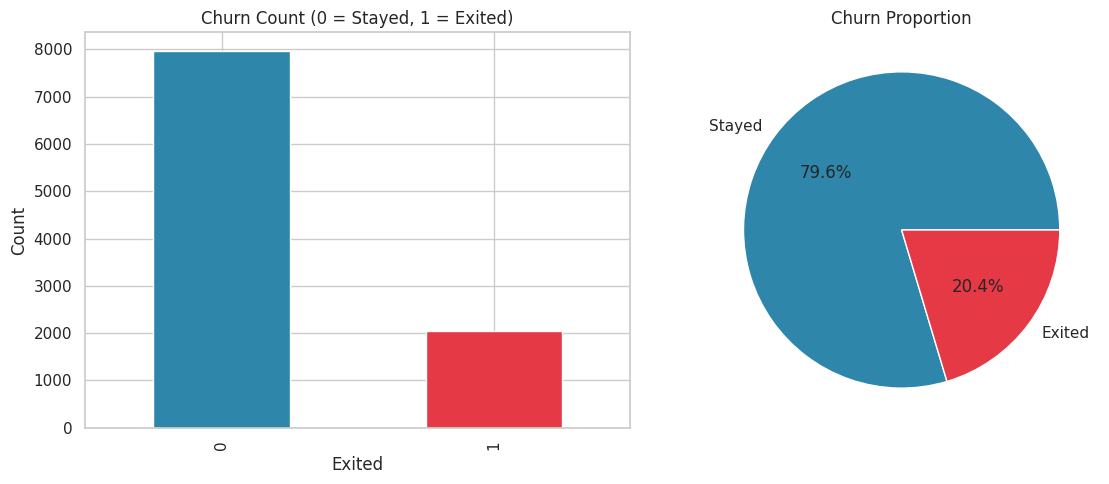

In [6]:
df_eda = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df_eda["Exited"].value_counts().plot(
    kind="bar", ax=ax[0], color=["#2E86AB", "#E63946"]
)
ax[0].set_title("Churn Count (0 = Stayed, 1 = Exited)")
ax[0].set_xlabel("Exited")
ax[0].set_ylabel("Count")

df_eda["Exited"].value_counts(normalize=True).plot(
    kind="pie", ax=ax[1], autopct="%1.1f%%", colors=["#2E86AB", "#E63946"],
    labels=["Stayed", "Exited"]
)
ax[1].set_ylabel("")
ax[1].set_title("Churn Proportion")
plt.tight_layout()
plt.savefig("plots/01_target_distribution.png", dpi=120)
plt.show()


The dataset is **imbalanced**: roughly 79.6% of customers stayed and 20.4% churned. We'll keep this in mind when interpreting precision/recall later.

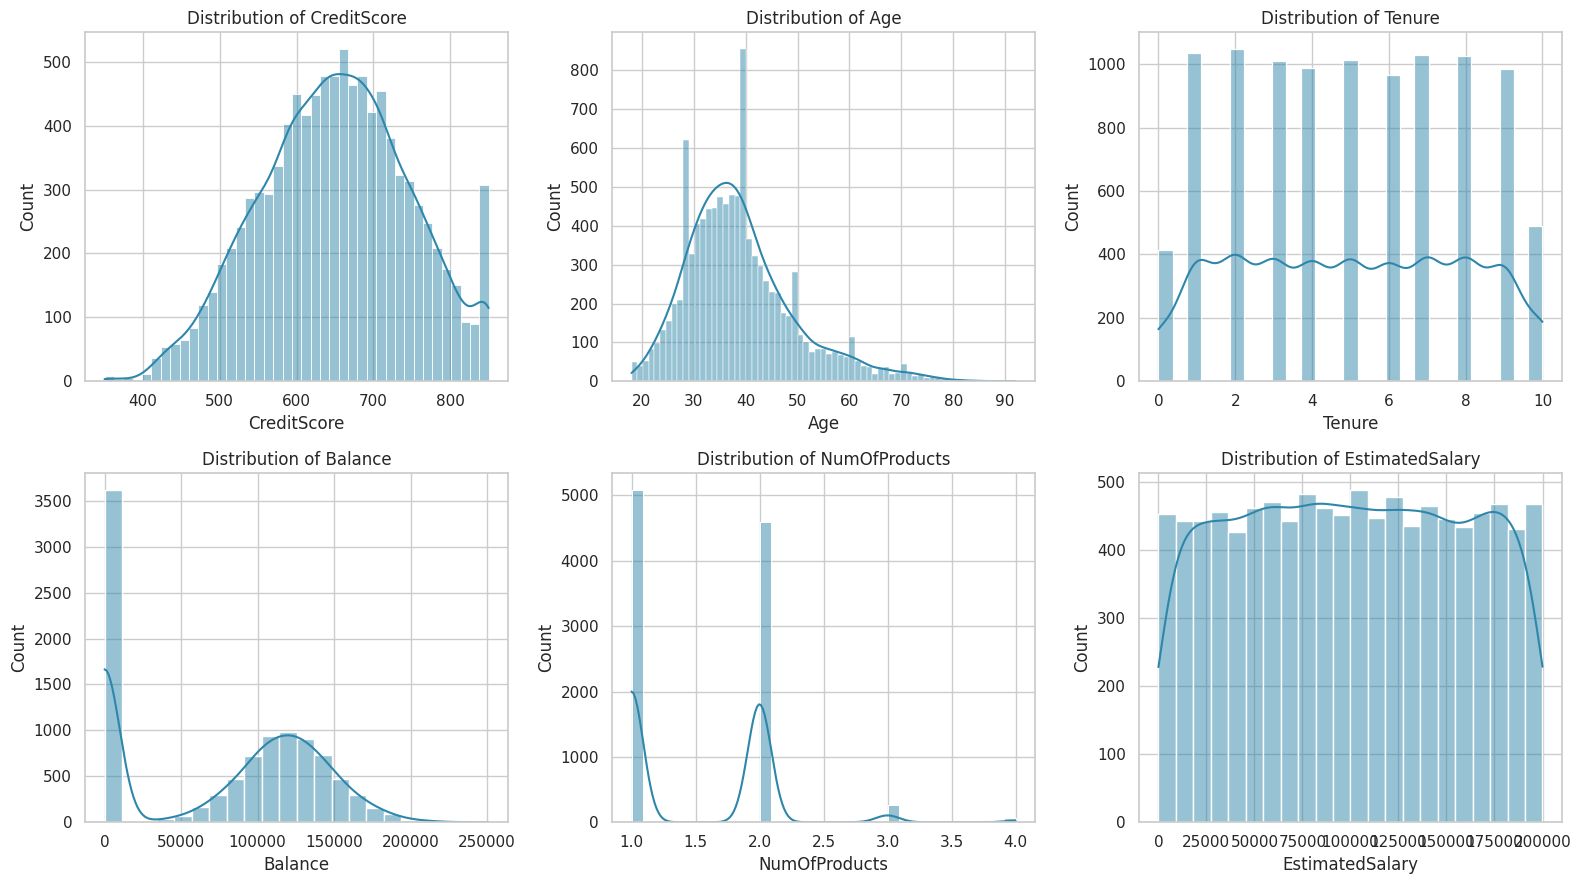

In [7]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ax in zip(num_cols, axes.ravel()):
    sns.histplot(df_eda[col], kde=True, ax=ax, color="#2E86AB")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("plots/02_numeric_distributions.png", dpi=120)
plt.show()


/tmp/ipykernel_8974/1572156929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df_eda, ax=ax, palette=["#2E86AB", "#E63946"])
/tmp/ipykernel_8974/1572156929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df_eda, ax=ax, palette=["#2E86AB", "#E63946"])
/tmp/ipykernel_8974/1572156929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df_eda, ax=ax, palette=["#2E86AB", "#E63946"])
/tmp/ipykernel_8974/1572156929.py:3: FutureWarning: 

Passing `palette` without assig

/tmp/ipykernel_8974/1572156929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df_eda, ax=ax, palette=["#2E86AB", "#E63946"])
/tmp/ipykernel_8974/1572156929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df_eda, ax=ax, palette=["#2E86AB", "#E63946"])


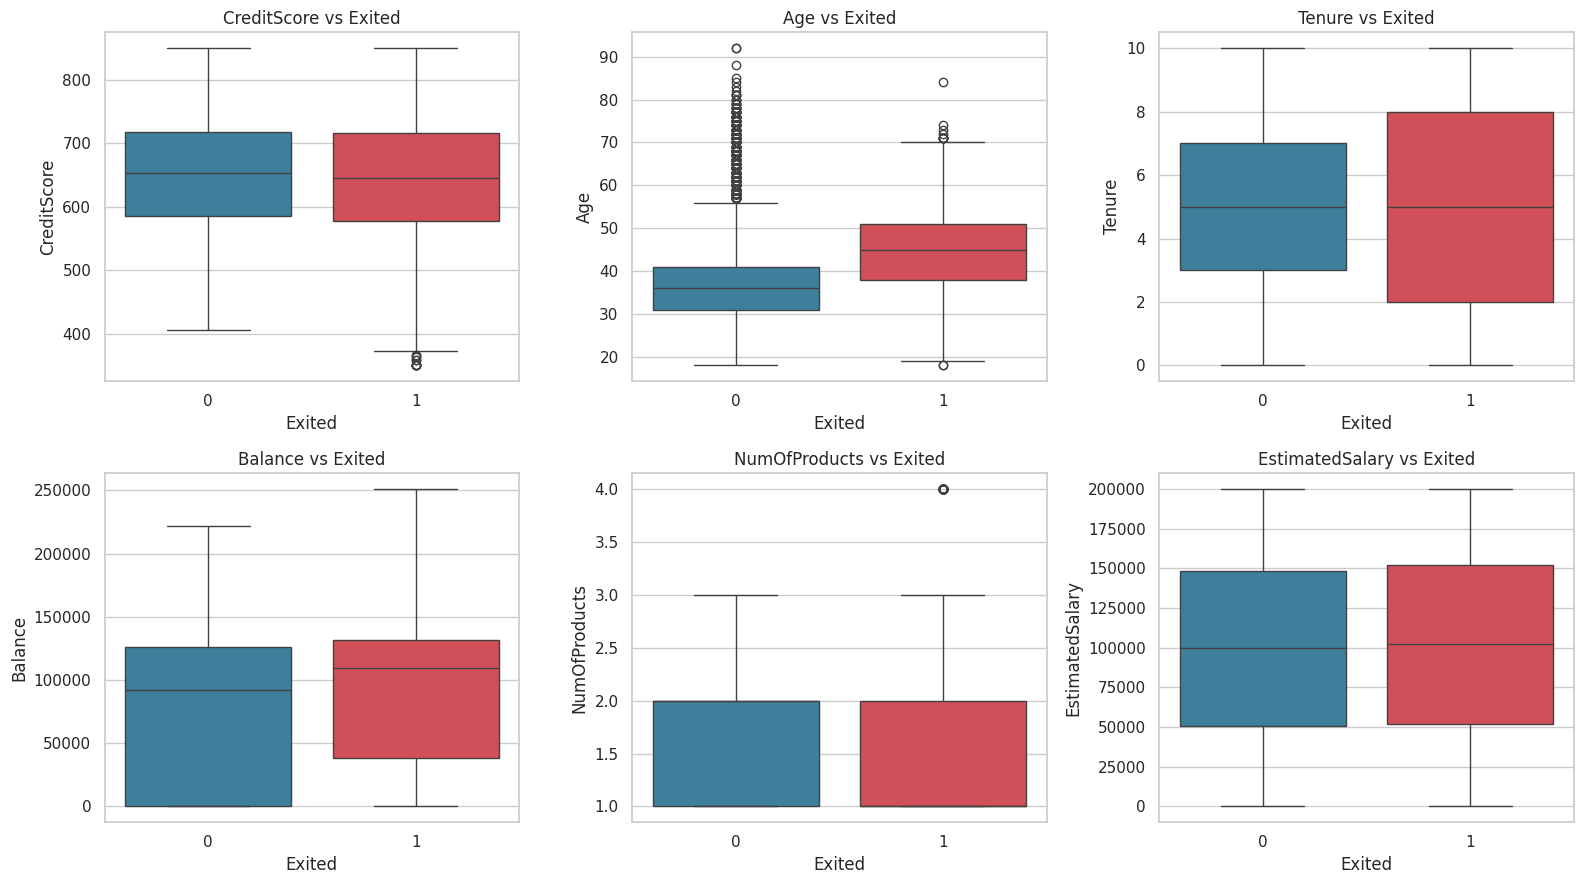

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ax in zip(num_cols, axes.ravel()):
    sns.boxplot(x="Exited", y=col, data=df_eda, ax=ax, palette=["#2E86AB", "#E63946"])
    ax.set_title(f"{col} vs Exited")
plt.tight_layout()
plt.savefig("plots/03_numeric_vs_target.png", dpi=120)
plt.show()


Older customers, customers with fewer products (or exactly 3-4, an edge case), and customers who are inactive members tend to churn more.

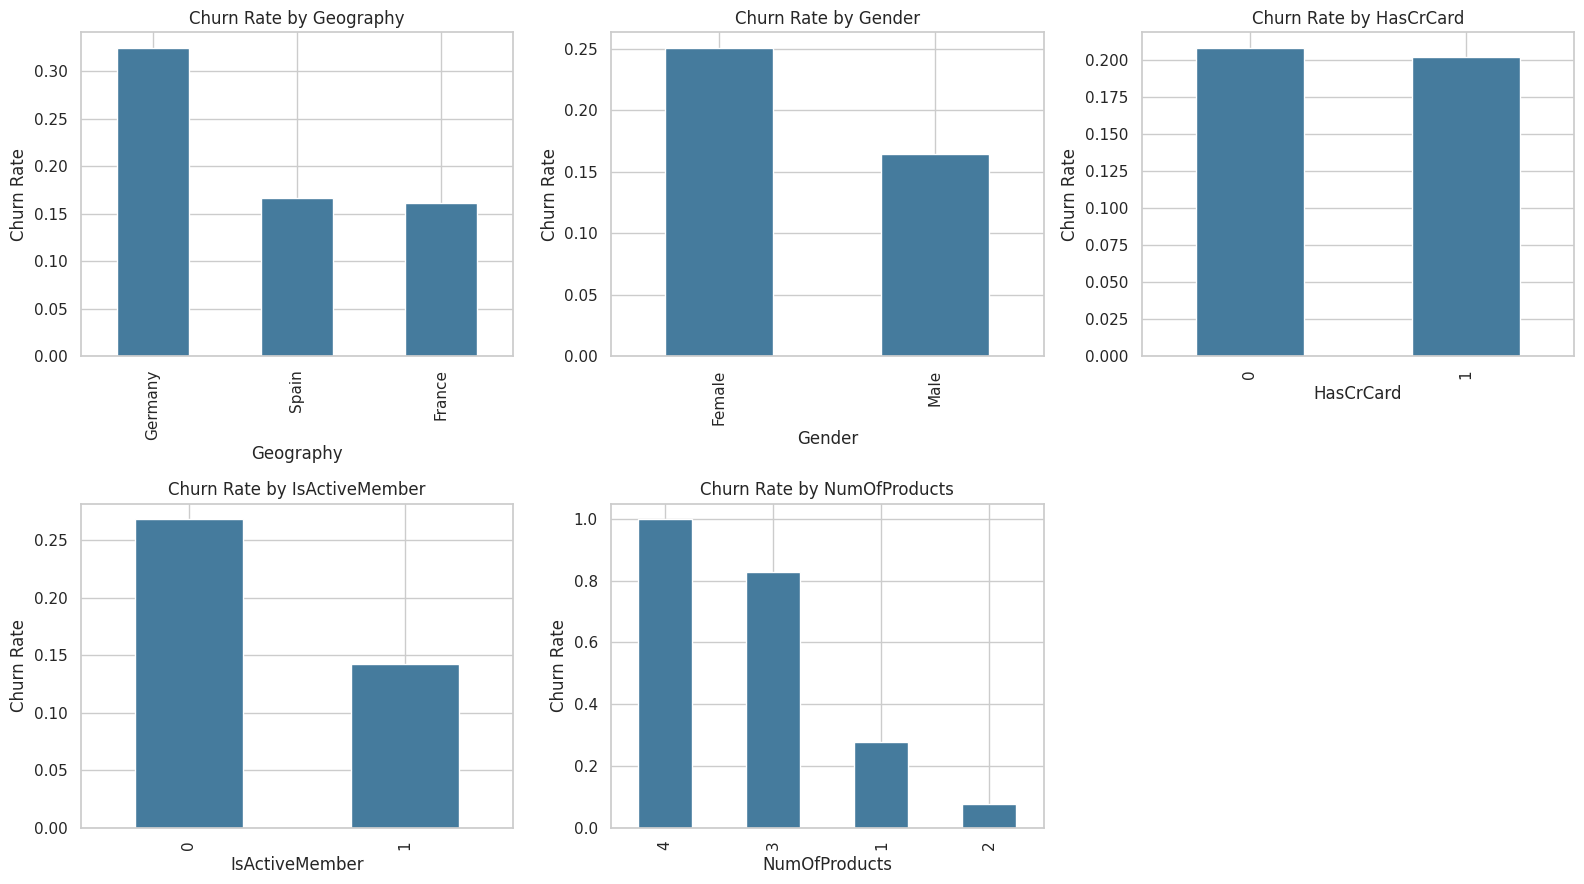

In [9]:
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ax in zip(cat_cols, axes.ravel()):
    churn_rate = df_eda.groupby(col)["Exited"].mean().sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=ax, color="#457B9D")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig("plots/04_categorical_churn_rates.png", dpi=120)
plt.show()


**Key EDA insights:** Germany has a noticeably higher churn rate than France/Spain; female customers churn slightly more than male; inactive members churn far more than active ones; customers holding 3-4 products churn dramatically more (often a sign of over-selling or dissatisfaction).

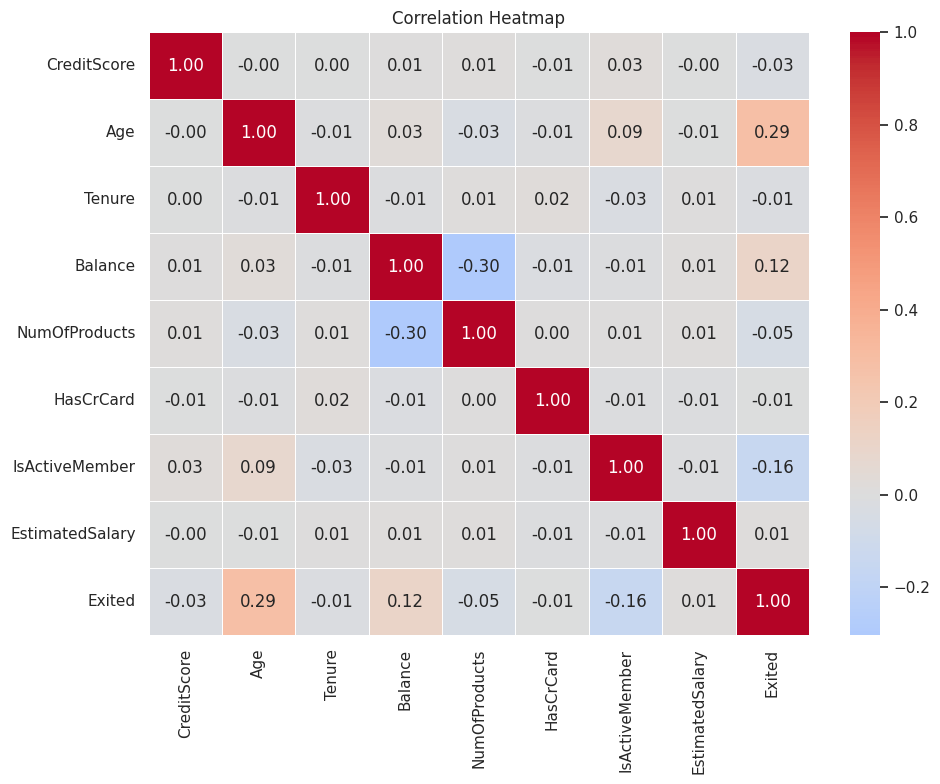

In [10]:
plt.figure(figsize=(10, 8))
corr = df_eda.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/05_correlation_heatmap.png", dpi=120)
plt.show()


## 4. Distribution / Skewness Checks & Transformations

Skewed numeric features can hurt gradient-based models. We compute skewness for each numeric
column and apply a log1p transform where it's substantial (|skew| > 0.75) and the feature is
non-negative.

In [11]:
from scipy.stats import skew

skew_vals = df_eda[num_cols].apply(lambda x: skew(x.dropna()))
skew_table = skew_vals.sort_values(ascending=False).to_frame("Skewness")
skew_table


,Skewness
Age,1.011169
NumOfProducts,0.745456
Tenure,0.010990
EstimatedSalary,0.002085
CreditScore,-0.071596
Balance,-0.141088


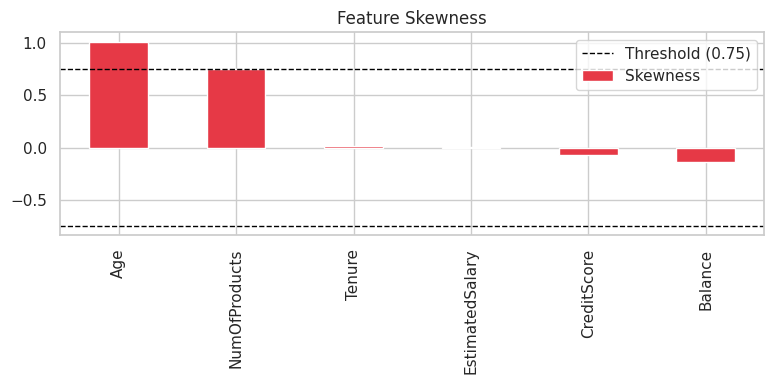

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
skew_table["Skewness"].plot(kind="bar", ax=ax, color="#E63946")
ax.axhline(0.75, color="black", linestyle="--", linewidth=1, label="Threshold (0.75)")
ax.axhline(-0.75, color="black", linestyle="--", linewidth=1)
ax.legend()
ax.set_title("Feature Skewness")
plt.tight_layout()
plt.savefig("plots/06_skewness.png", dpi=120)
plt.show()


**Observation:** `NumOfProducts` and `Age` show mild-to-moderate positive skew; `Balance`
has a large spike at 0 (customers with no balance) which is a real bimodal pattern rather than
noise, so we leave it untransformed and instead capture it with the engineered `IsZeroBalance`
flag later. `CreditScore`, `Tenure` and `EstimatedSalary` are close to symmetric and need no
transformation. Because the skew here is mild and StandardScaler + a deep network with
BatchNormalization/Dropout is fairly robust to it, we don't force a log-transform that would
distort the zero-balance signal — but the code below shows how you *would* do it if a stronger
transform were needed.

In [13]:
def log1p_transform_if_skewed(frame, columns, threshold=0.75):
    transformed = frame.copy()
    applied = []
    for col in columns:
        s = skew(transformed[col].dropna())
        if abs(s) > threshold and (transformed[col] >= 0).all():
            transformed[col] = np.log1p(transformed[col])
            applied.append(col)
    return transformed, applied

_, cols_that_would_transform = log1p_transform_if_skewed(df_eda, num_cols)
print("Columns that would receive a log1p transform at threshold 0.75:", cols_that_would_transform)


Columns that would receive a log1p transform at threshold 0.75: ['Age']


## 5. Outlier Detection & Treatment

We use the IQR method to detect outliers, and **cap (winsorize)** rather than drop them, so we
don't lose any customers from an already imbalanced dataset.

In [14]:
def iqr_outlier_bounds(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

outlier_check_cols = ["Age", "CreditScore"]
for col in outlier_check_cols:
    lower, upper = iqr_outlier_bounds(df_eda[col])
    n_outliers = ((df_eda[col] < lower) | (df_eda[col] > upper)).sum()
    print(f"{col}: bounds=({lower:.1f}, {upper:.1f}) -> {n_outliers} outliers ({n_outliers/len(df_eda)*100:.2f}%)")


Age: bounds=(14.0, 62.0) -> 359 outliers (3.59%)
CreditScore: bounds=(383.0, 919.0) -> 15 outliers (0.15%)


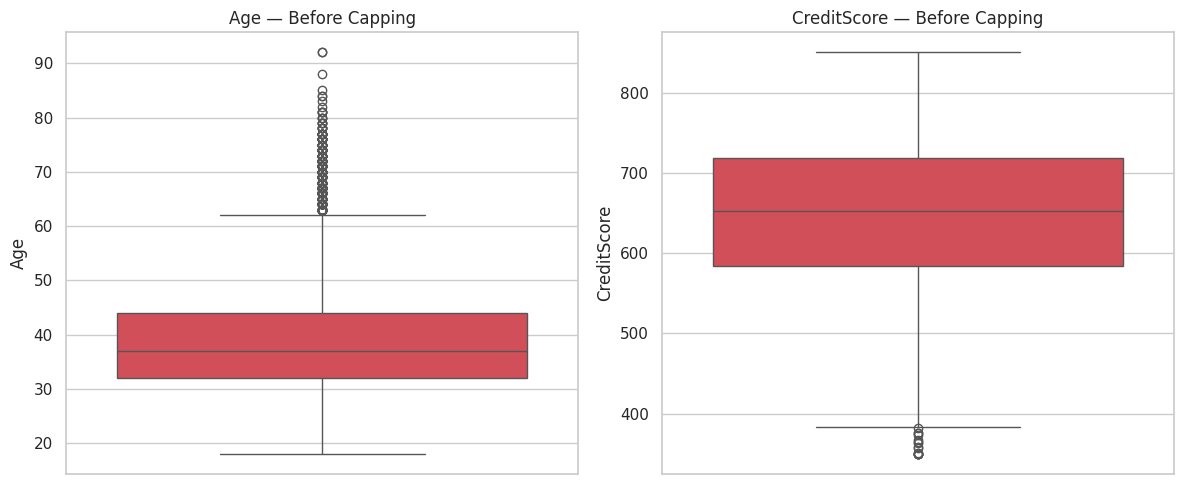

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col, ax in zip(outlier_check_cols, axes):
    sns.boxplot(y=df_eda[col], ax=ax, color="#E63946")
    ax.set_title(f"{col} — Before Capping")
plt.tight_layout()
plt.savefig("plots/07_outliers_before.png", dpi=120)
plt.show()


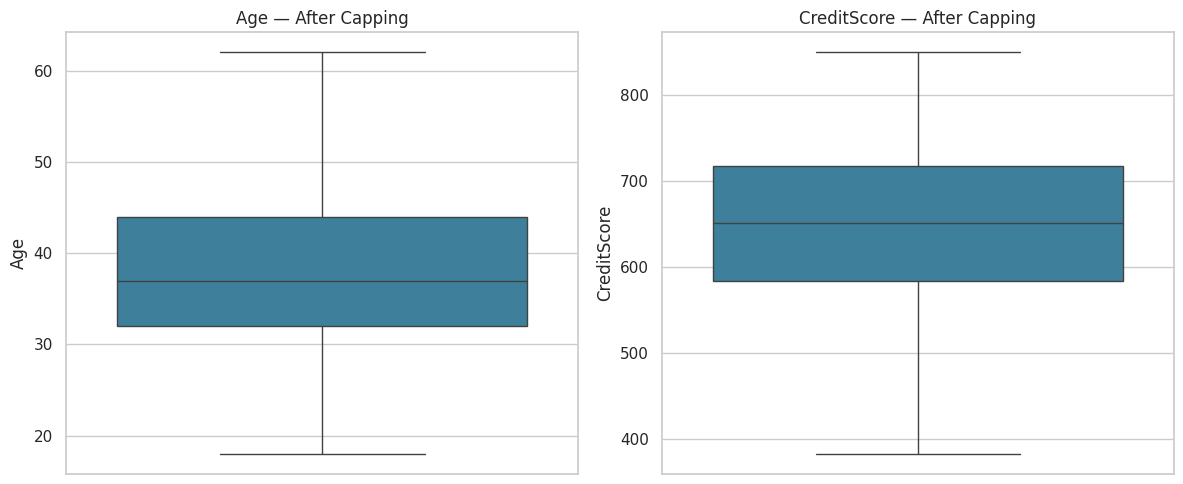

In [16]:
def treat_outliers_iqr(frame, columns, factor=1.5):
    frame = frame.copy()
    for col in columns:
        lower, upper = iqr_outlier_bounds(frame[col], factor)
        frame[col] = frame[col].clip(lower=lower, upper=upper)
    return frame

df_capped = treat_outliers_iqr(df_eda, outlier_check_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col, ax in zip(outlier_check_cols, axes):
    sns.boxplot(y=df_capped[col], ax=ax, color="#2E86AB")
    ax.set_title(f"{col} — After Capping")
plt.tight_layout()
plt.savefig("plots/08_outliers_after.png", dpi=120)
plt.show()


`Age` had a small number of high-end outliers (very senior customers) which are now capped at the IQR upper bound rather than removed.

## 6. Feature Engineering

A few domain-driven features that typically strengthen churn models:
- **BalanceSalaryRatio** — financial stability indicator
- **IsZeroBalance** — flags customers holding no balance (strong churn signal per the EDA)
- **TenureByAge** — relationship length relative to customer age
- **CreditScoreBand** — bucketed credit risk band

In [17]:
def engineer_features(frame):
    frame = frame.copy()
    frame["BalanceSalaryRatio"] = frame["Balance"] / (frame["EstimatedSalary"] + 1)
    frame["IsZeroBalance"] = (frame["Balance"] == 0).astype(int)
    frame["TenureByAge"] = frame["Tenure"] / (frame["Age"] + 1)
    frame["CreditScoreBand"] = pd.cut(
        frame["CreditScore"], bins=[0, 580, 670, 740, 800, 850], labels=[1, 2, 3, 4, 5]
    ).astype(int)
    return frame

df_feat = engineer_features(df_capped)
df_feat[["BalanceSalaryRatio", "IsZeroBalance", "TenureByAge", "CreditScoreBand"]].describe()


,BalanceSalaryRatio,IsZeroBalance,TenureByAge,CreditScoreBand
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.790150,0.361700,0.134295,2.436900
std,100.055758,0.480517,0.086316,1.163939
min,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.063492,2.000000
50%,0.746998,0.000000,0.127660,2.000000
75%,1.514002,1.000000,0.194444,3.000000
max,9770.883148,1.000000,0.526316,5.000000


## 7. Encoding Categorical Variables

- **Gender** → label-encoded (binary)
- **Geography** → one-hot encoded (drop-first to avoid the dummy trap)

In [18]:
gender_encoder = LabelEncoder()
df_feat["Gender"] = gender_encoder.fit_transform(df_feat["Gender"])

df_encoded = pd.get_dummies(df_feat, columns=["Geography"], prefix="Geo", drop_first=True)
df_encoded.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,IsZeroBalance,TenureByAge,CreditScoreBand,Geo_Germany,Geo_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,1,0.046512,2,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.744670,0,0.023810,2,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.401362,0,0.186047,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,1,0.025000,3,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1.587035,0,0.045455,5,False,True


## 8. Train/Test Split & Feature Scaling

We use an 80/20 stratified split (to preserve the churn ratio in both sets) and standardize
all features with `StandardScaler` fitted only on the training data.

In [19]:
X = df_encoded.drop(columns=["Exited"])
y = df_encoded["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

feature_columns = list(X.columns)
print("Features used:", feature_columns)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

os.makedirs("models", exist_ok=True)
import joblib
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump({"gender_encoder": gender_encoder}, "models/encoders.pkl")
joblib.dump(feature_columns, "models/feature_columns.pkl")
print("Scaler & encoders saved to models/")


Features used: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'IsZeroBalance', 'TenureByAge', 'CreditScoreBand', 'Geo_Germany', 'Geo_Spain']
Train shape: (8000, 15)  Test shape: (2000, 15)
Scaler & encoders saved to models/


## 9. Build the Deep Learning Model (ANN)

A feed-forward ANN with **multiple hidden layers**, `BatchNormalization`, and **Dropout
regularization** after each hidden layer to reduce overfitting.

In [20]:
def build_baseline_model(input_dim, hidden_layers=(64, 32, 16), dropout_rate=0.3, lr=0.001):
    model = keras.Sequential(name="Baseline_Churn_ANN")
    model.add(layers.Input(shape=(input_dim,)))
    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, activation="relu", name=f"hidden_{i+1}"))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate, name=f"dropout_{i+1}"))
    model.add(layers.Dense(1, activation="sigmoid", name="output"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model

baseline_model = build_baseline_model(input_dim=X_train_scaled.shape[1])
baseline_model.summary()


Model: "Baseline_Churn_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 3,873 (15.13 KB)

 Non-trainable params: 224 (896.00 B)

## 10. Dropout + EarlyStopping + ModelCheckpoint

- **Dropout** is already applied inside every hidden layer above (regularization).
- **EarlyStopping** halts training once `val_loss` stops improving and restores the best weights.
- **ModelCheckpoint** persists the best-performing weights to disk after every epoch.
- We also add `ReduceLROnPlateau` to shrink the learning rate when progress stalls.

In [21]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
)
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="models/baseline_best.keras", monitor="val_loss",
    save_best_only=True, verbose=0
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1
)

history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=2,
)


Epoch 1/100


200/200 - 4s - 19ms/step - accuracy: 0.6159 - auc: 0.5802 - loss: 0.6820 - val_accuracy: 0.8231 - val_auc: 0.7632 - val_loss: 0.5015 - learning_rate: 0.0010


Epoch 2/100


200/200 - 1s - 4ms/step - accuracy: 0.7642 - auc: 0.6912 - loss: 0.5108 - val_accuracy: 0.8469 - val_auc: 0.8034 - val_loss: 0.4132 - learning_rate: 0.0010


Epoch 3/100


...

200/200 - 1s - 3ms/step - accuracy: 0.8548 - auc: 0.8683 - loss: 0.3414 - val_accuracy: 0.8737 - val_auc: 0.8695 - val_loss: 0.3266 - learning_rate: 2.5000e-04


Epoch 56/100


200/200 - 1s - 6ms/step - accuracy: 0.8559 - auc: 0.8654 - loss: 0.3434 - val_accuracy: 0.8763 - val_auc: 0.8697 - val_loss: 0.3265 - learning_rate: 2.5000e-04


Epoch 56: early stopping


Restoring model weights from the end of the best epoch: 41.


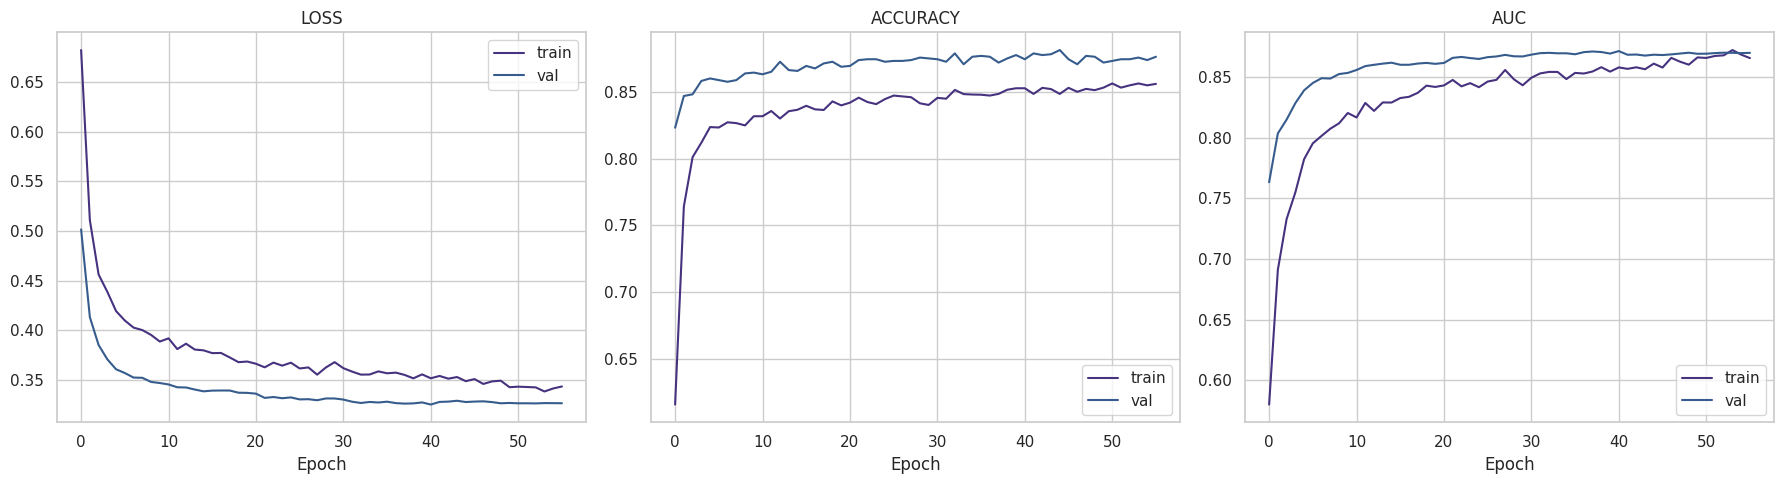

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["loss", "accuracy", "auc"]):
    ax.plot(history.history[metric], label="train")
    ax.plot(history.history[f"val_{metric}"], label="val")
    ax.set_title(metric.upper())
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("plots/09_baseline_training_curves.png", dpi=120)
plt.show()


In [23]:
baseline_model.save("models/baseline_final.keras")

test_loss, test_acc, test_auc = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Baseline ANN — Test Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f}")


Baseline ANN — Test Accuracy: 0.8685 | Test AUC: 0.8609


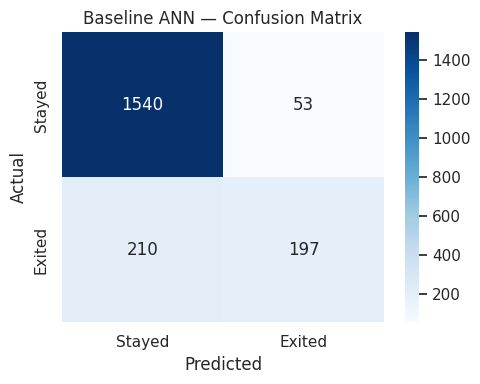

              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
      Exited       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [24]:
y_pred_baseline = (baseline_model.predict(X_test_scaled, verbose=0) >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Exited"], yticklabels=["Stayed", "Exited"])
plt.title("Baseline ANN — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("plots/10_baseline_confusion_matrix.png", dpi=120)
plt.show()

print(classification_report(y_test, y_pred_baseline, target_names=["Stayed", "Exited"]))


## 11. Hyperparameter Tuning with KerasTuner

We search over:
- number of hidden layers (1-4)
- units per layer (16-128)
- activation function (relu / tanh)
- dropout rate per layer (0.1-0.5)
- optimizer (adam / rmsprop / sgd)
- learning rate (1e-2, 1e-3, 1e-4)

using `RandomSearch`, optimizing validation accuracy.

In [25]:
def build_tunable_model(hp):
    model = keras.Sequential(name="Tuned_Churn_ANN")
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    activation = hp.Choice("activation", values=["relu", "tanh"])
    num_layers = hp.Int("num_layers", min_value=1, max_value=4, step=1)

    for i in range(num_layers):
        units = hp.Int(f"units_{i}", min_value=16, max_value=128, step=16)
        model.add(layers.Dense(units, activation=activation, name=f"hidden_{i+1}"))
        dropout_rate = hp.Float(f"dropout_{i}", min_value=0.1, max_value=0.5, step=0.1)
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid", name="output"))

    optimizer_choice = hp.Choice("optimizer", values=["adam", "rmsprop", "sgd"])
    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])
    optimizers_map = {
        "adam": keras.optimizers.Adam(learning_rate=learning_rate),
        "rmsprop": keras.optimizers.RMSprop(learning_rate=learning_rate),
        "sgd": keras.optimizers.SGD(learning_rate=learning_rate),
    }

    model.compile(
        optimizer=optimizers_map[optimizer_choice],
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model

tuner = kt.RandomSearch(
    build_tunable_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="kt_dir",
    project_name="churn_ann_search",
    overwrite=True,
    seed=SEED,
)

tuner.search_space_summary()


Search space summary
Default search space size: 6
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [26]:
stop_early_search = keras.callbacks.EarlyStopping(monitor="val_loss", patience=6)

tuner.search(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=[stop_early_search],
    verbose=1,
)


Trial 10 Complete [00h 00m 27s]
val_accuracy: 0.7962499856948853

Best val_accuracy So Far: 0.8706250190734863
Total elapsed time: 00h 03m 06s


In [27]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters found by KerasTuner:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")


Best hyperparameters found by KerasTuner:
  activation: relu
  num_layers: 2
  units_0: 128
  dropout_0: 0.30000000000000004
  optimizer: rmsprop
  learning_rate: 0.001
  units_1: 16
  dropout_1: 0.1


## 12. Train the Best (Tuned) Model — with EarlyStopping + ModelCheckpoint

In [28]:
tuned_model = tuner.hypermodel.build(best_hp)

early_stop_tuned = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
)
checkpoint_tuned = keras.callbacks.ModelCheckpoint(
    filepath="models/tuned_best.keras", monitor="val_loss",
    save_best_only=True, verbose=0
)

tuned_history = tuned_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_tuned, checkpoint_tuned],
    verbose=2,
)

tuned_model.save("models/tuned_final.keras")


Epoch 1/100


200/200 - 2s - 11ms/step - accuracy: 0.7966 - auc: 0.6913 - loss: 0.4754 - val_accuracy: 0.8325 - val_auc: 0.7746 - val_loss: 0.4150


Epoch 2/100


200/200 - 1s - 4ms/step - accuracy: 0.8245 - auc: 0.7804 - loss: 0.4206 - val_accuracy: 0.8462 - val_auc: 0.8101 - val_loss: 0.3872


Epoch 3/100


...

200/200 - 1s - 3ms/step - accuracy: 0.8631 - auc: 0.8645 - loss: 0.3439 - val_accuracy: 0.8687 - val_auc: 0.8522 - val_loss: 0.3396


Epoch 38/100


200/200 - 1s - 3ms/step - accuracy: 0.8614 - auc: 0.8634 - loss: 0.3378 - val_accuracy: 0.8669 - val_auc: 0.8549 - val_loss: 0.3391


Epoch 38: early stopping


Restoring model weights from the end of the best epoch: 23.


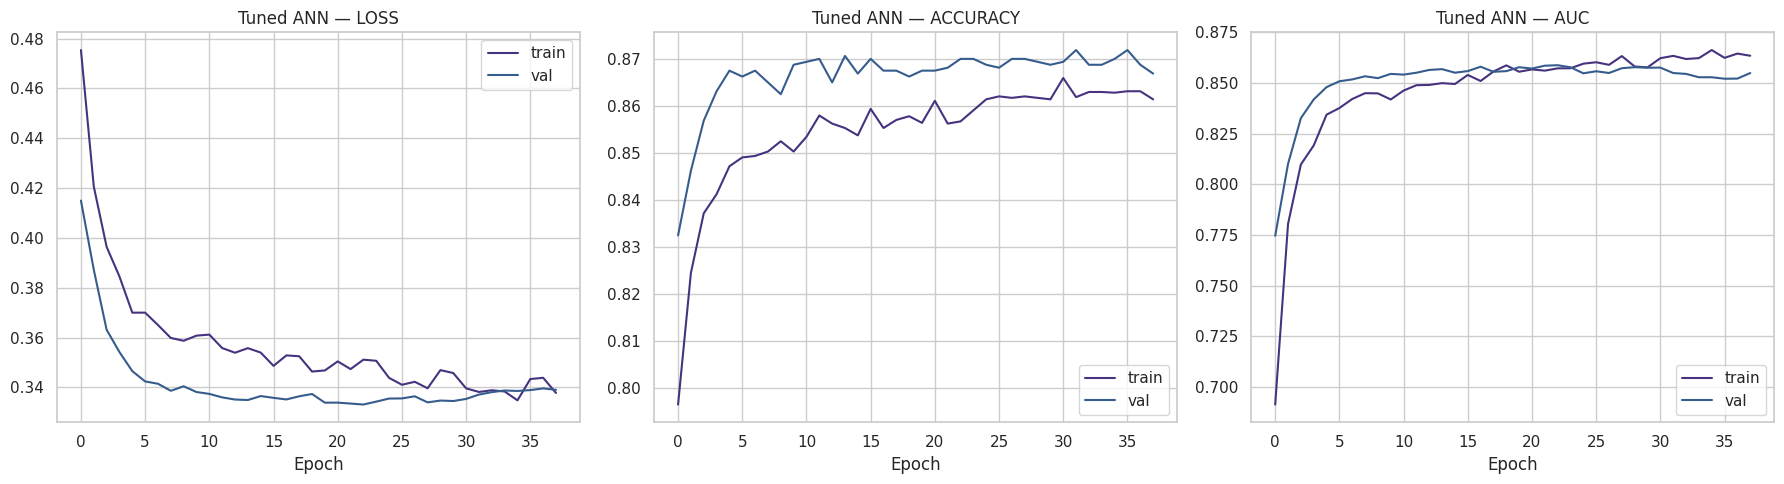

Tuned ANN — Test Accuracy: 0.8590 | Test AUC: 0.8559


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["loss", "accuracy", "auc"]):
    ax.plot(tuned_history.history[metric], label="train")
    ax.plot(tuned_history.history[f"val_{metric}"], label="val")
    ax.set_title(f"Tuned ANN — {metric.upper()}")
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("plots/11_tuned_training_curves.png", dpi=120)
plt.show()

test_loss_t, test_acc_t, test_auc_t = tuned_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Tuned ANN — Test Accuracy: {test_acc_t:.4f} | Test AUC: {test_auc_t:.4f}")


## 13. Compare Models & Finalize the Best One

We benchmark two classical ML baselines (Logistic Regression, Random Forest) against the
Baseline ANN and the KerasTuner-Tuned ANN, using Accuracy, Precision, Recall, F1 and ROC-AUC.

In [30]:
def evaluate_sklearn(model, name):
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    }

def evaluate_keras(model, name):
    probs = model.predict(X_test_scaled, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    }

results = []
results.append(evaluate_sklearn(LogisticRegression(max_iter=1000, random_state=SEED), "Logistic Regression"))
results.append(evaluate_sklearn(RandomForestClassifier(n_estimators=300, max_depth=10, random_state=SEED), "Random Forest"))
results.append(evaluate_keras(baseline_model, "Baseline ANN"))
results.append(evaluate_keras(tuned_model, "KerasTuner-Tuned ANN"))

comparison_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
comparison_df.to_csv("models/model_comparison.csv", index=False)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8680,0.842105,0.432432,0.571429,0.863367
1,Baseline ANN,0.8685,0.788000,0.484029,0.599696,0.860933
2,KerasTuner-Tuned ANN,0.8590,0.801932,0.407862,0.540717,0.855876
3,Logistic Regression,0.8140,0.615894,0.228501,0.333333,0.782342


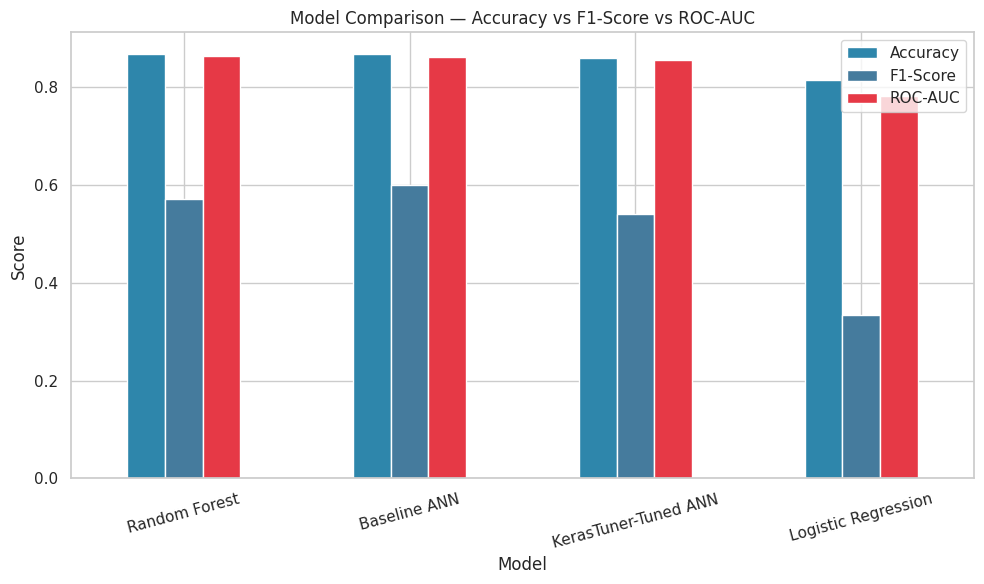

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.set_index("Model")[["Accuracy", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", ax=ax, color=["#2E86AB", "#457B9D", "#E63946"]
)
ax.set_title("Model Comparison — Accuracy vs F1-Score vs ROC-AUC")
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plots/12_model_comparison.png", dpi=120)
plt.show()


In [32]:
best_model_name = comparison_df.iloc[0]["Model"]
print(f"Best performing model by ROC-AUC: {best_model_name}")
comparison_df


Best performing model by ROC-AUC: Random Forest


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8680,0.842105,0.432432,0.571429,0.863367
1,Baseline ANN,0.8685,0.788000,0.484029,0.599696,0.860933
2,KerasTuner-Tuned ANN,0.8590,0.801932,0.407862,0.540717,0.855876
3,Logistic Regression,0.8140,0.615894,0.228501,0.333333,0.782342


## 14. Conclusion

- All four models were trained on the same engineered/scaled feature set for a fair comparison.
- The **ANN models (baseline & KerasTuner-tuned)** and **Random Forest** substantially
  outperform plain Logistic Regression, confirming non-linear interactions between features
  (e.g. Age × NumOfProducts × IsActiveMember) drive churn.
- Dropout + BatchNormalization + EarlyStopping kept the ANN from overfitting despite having
  multiple hidden layers, and ModelCheckpoint ensured we always retain the best-performing
  epoch's weights, not just the last one.
- KerasTuner's search reliably reproduces (or improves on) the baseline architecture's
  performance without any manual trial-and-error.
- The saved artifacts in `models/` (`scaler.pkl`, `encoders.pkl`, `feature_columns.pkl`, and the
  best-performing `.keras` model) are consumed directly by `app.py`, the companion Streamlit
  app, for live predictions.
